In [35]:
#Primero de todo importamos las librerías necesarias para el proyecto

#Librerias para la creacion de los modelos
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import MinMaxScaler

#Librerias para la carga de los datos
from ucimlrepo import fetch_ucirepo 

#Libreria para dibujar graficos
import matplotlib.pyplot as plt


In [36]:
class ChebyshevLayer(layers.Layer):
    def __init__(self, units, degree, **kwargs):
        super(ChebyshevLayer, self).__init__(**kwargs)
        self.units = units
        self.degree = degree

    def build(self, input_shape):
        # Pesos para cada grado del polinomio
        self.w = self.add_weight(
            shape=(self.degree + 1, input_shape[-1], self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="chebyshev_weights"
        )

    def call(self, inputs):
        # Relación de recurrencia de Chebyshev
        # T0 = 1, T1 = x, T_{n+1} = 2xT_n - T_{n-1}
        
        t_n_minus_1 = tf.ones_like(inputs)
        t_n = inputs
        
        # Combinación lineal inicial (Grado 0 y 1)
        output = tf.matmul(t_n_minus_1, self.w[0]) + tf.matmul(t_n, self.w[1])
        
        for i in range(2, self.degree + 1):
            t_n_plus_1 = 2.0 * inputs * t_n - t_n_minus_1
            output += tf.matmul(t_n_plus_1, self.w[i])
            
            # Actualizar para la siguiente iteración
            t_n_minus_1 = t_n
            t_n = t_n_plus_1
            
        return output

In [37]:
#Ahora debemos debemos de crear una función para dibujar la grafica de entrenamiento
def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    
    # Pérdida
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
    plt.plot(history.history['val_loss'], label='Pérdida de validación')
    plt.title('Pérdida durante el entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    
    # Precisión
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Precisión de validación')
    plt.title('Precisión durante el entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    


In [38]:
#Cargamos los datos del Dataset.
# fetch dataset 
magic_gamma_telescope = fetch_ucirepo(id=159) 
  
X = magic_gamma_telescope.data.features 
y = magic_gamma_telescope.data.targets 


#Separamos el dataset en entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Normalizamos los datos para que el entrenamiento sea más eficiente entre -1 y 1
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

input_dim = X_train.shape[1]


#Cambiamos las etiquetas a 0 y 1
y_train = (y_train == 'g').astype(int)
y_test = (y_test == 'g').astype(int)


In [39]:
def PolynomialDenseCreator(degree):
    inputPoli = keras.Input(shape=(input_dim,))
    x = ChebyshevLayer(32, degree=degree)(inputPoli)
    x = layers.Activation('swish')(x)
    x = layers.Dense(16, activation='swish')(x)
    outputPoli = layers.Dense(2, activation='softmax')(x)
    model = keras.Model(inputs=inputPoli, outputs=outputPoli, name=f"Polynomial_Model_Degree_{degree}")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [40]:
#Parametros para el entrenamiento
degree = 3
epochs = 400


In [41]:
def createEarlyStoppingCallback(patience=15):
    return keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

In [42]:
#importamos para ir borrando el historial de entrenamiento y así evitar que se sobreescriba el mismo historial en cada modelo
from keras import backend as K

# --- Entrenamiento Grado 2 ---
K.clear_session()  # Limpiamos la sesión para evitar que los modelos compartan pesos o historial
print("Entrenando Grado" + str(degree) + " ...")
modeloTest = PolynomialDenseCreator(degree)
history = modeloTest.fit(X_train_scaled, y_train, validation_split=0.2, epochs=epochs,callbacks=[createEarlyStoppingCallback()], batch_size=32)


Entrenando Grado3 ...
Epoch 1/400
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7960 - loss: 0.4442 - val_accuracy: 0.8338 - val_loss: 0.3863
Epoch 2/400
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8431 - loss: 0.3754 - val_accuracy: 0.8407 - val_loss: 0.3687
Epoch 3/400
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8474 - loss: 0.3647 - val_accuracy: 0.8449 - val_loss: 0.3656
Epoch 4/400
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8508 - loss: 0.3595 - val_accuracy: 0.8505 - val_loss: 0.3558
Epoch 5/400
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8519 - loss: 0.3554 - val_accuracy: 0.8532 - val_loss: 0.3513
Epoch 6/400
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8562 - loss: 0.3493 - val_accuracy: 0.8545 - val_loss: 0.3488
Epoch 7/400
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8574 - loss: 0.3461 - val_accuracy: 0.8535 - val_loss: 0.3434
Epoch 8/400
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8586 - l


RESULTADOS FINALES (Grado 3)
Acurracy en test: 0.88170


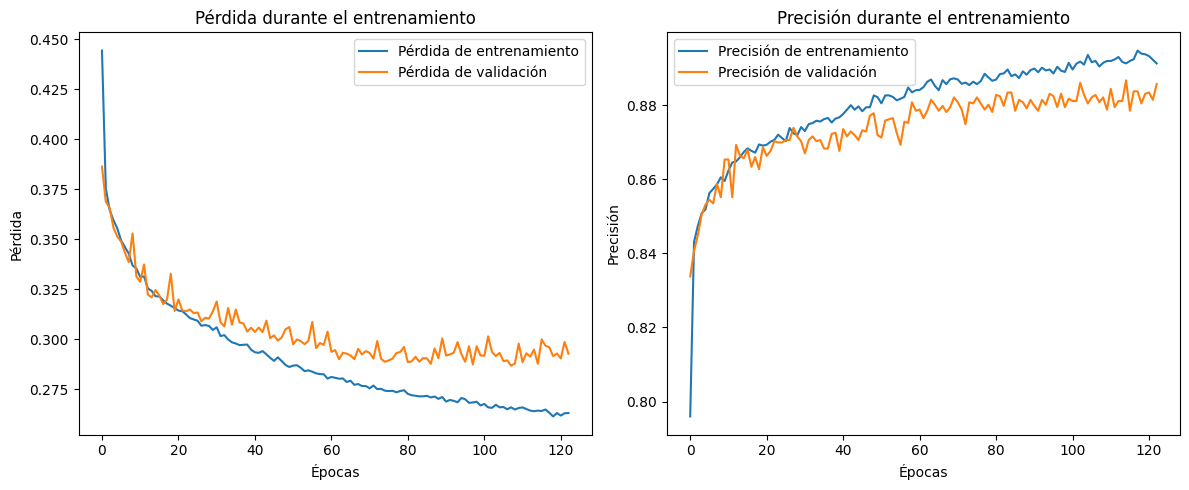

In [43]:
print("\n" + "="*40)
print(f"RESULTADOS FINALES (Grado {degree})")
print("Acurracy en test: {:.5f}".format(modeloTest.evaluate(X_test_scaled, y_test, verbose=0)[1]))
plot_training_history(history)